In [5]:
import pandas as pd
import numpy as np
import pickle

import torch
import torch.nn as nn

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import (
    Dataset,
    DataLoader
)

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
train_df = pd.read_csv("../dataset/train.csv")
test_df = pd.read_csv("../dataset/test.csv")

print(train_df.shape)
print(test_df.shape)

(14294, 2)
(3574, 2)


In [7]:
counter = Counter()

for text in train_df["text"]:
    counter.update(text.split())

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, freq in counter.items():

    if freq >= 2:

        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 12202


In [8]:
def encode_text(text, vocab):

    return [
        vocab.get(
            word,
            vocab["<UNK>"]
        )
        for word in text.split()
    ]

In [9]:
train_sequences = [
    encode_text(text, vocab)
    for text in train_df["text"]
]

test_sequences = [
    encode_text(text, vocab)
    for text in test_df["text"]
]

In [10]:
MAX_LEN = 100

def pad_sequence(sequence):

    if len(sequence) < MAX_LEN:

        sequence += [0] * (
            MAX_LEN - len(sequence)
        )

    else:

        sequence = sequence[:MAX_LEN]

    return sequence

In [11]:
train_sequences = [
    pad_sequence(seq)
    for seq in train_sequences
]

test_sequences = [
    pad_sequence(seq)
    for seq in test_sequences
]

In [12]:
X_train = torch.tensor(
    train_sequences,
    dtype=torch.long
)

X_test = torch.tensor(
    test_sequences,
    dtype=torch.long
)

y_train = torch.tensor(
    train_df["label"].values,
    dtype=torch.long
)

y_test = torch.tensor(
    test_df["label"].values,
    dtype=torch.long
)

In [13]:
class YouTubeDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [14]:
train_dataset = YouTubeDataset(
    X_train,
    y_train
)

test_dataset = YouTubeDataset(
    X_test,
    y_test
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [16]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(
        y_train.numpy()
    ),
    y=y_train.numpy()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

print(class_weights)

tensor([2.5699, 1.3239, 0.5389])


In [17]:
class ConvLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.conv1 = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=128,
            kernel_size=5,
            padding=2
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool1d(
            kernel_size=2
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(
            0.5
        )

        self.fc1 = nn.Linear(
            hidden_dim,
            64
        )

        self.fc2 = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        x = self.embedding(x)

        x = x.permute(0, 2, 1)

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = x.permute(0, 2, 1)

        _, (hidden, _) = self.lstm(x)

        x = hidden[-1]

        x = self.dropout(x)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

In [18]:
VOCAB_SIZE = len(vocab)
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 3

In [19]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [20]:
model = ConvLSTM(
    VOCAB_SIZE,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_CLASSES
).to(device)

In [21]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [25]:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += y_batch.size(0)

        correct += (
            predicted == y_batch
        ).sum().item()

    train_acc = (
        100 * correct / total
    )

    return (
        total_loss / len(train_loader),
        train_acc
    )

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)

            outputs = model(X_batch)

            _, predicted = torch.max(
                outputs,
                1
            )

            y_true.extend(
                y_batch.numpy()
            )

            y_pred.extend(
                predicted.cpu().numpy()
            )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    return (
        acc,
        precision,
        recall,
        f1,
        y_true,
        y_pred
    )

In [27]:
EPOCHS = 10

history = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    acc, precision, recall, f1, _, _ = evaluate_model(
        model,
        test_loader,
        device
    )

    history.append([
        epoch + 1,
        train_loss,
        train_acc,
        acc,
        precision,
        recall,
        f1
    ])

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Test Acc: {acc:.4f} "
        f"F1: {f1:.4f}"
    )

Epoch [1/10] Loss: 0.5569 Train Acc: 80.27% Test Acc: 0.6463 F1: 0.6700
Epoch [2/10] Loss: 0.4819 Train Acc: 83.35% Test Acc: 0.6732 F1: 0.6889
Epoch [3/10] Loss: 0.4298 Train Acc: 85.32% Test Acc: 0.6427 F1: 0.6653
Epoch [4/10] Loss: 0.3699 Train Acc: 87.62% Test Acc: 0.6626 F1: 0.6763
Epoch [5/10] Loss: 0.3318 Train Acc: 88.78% Test Acc: 0.6572 F1: 0.6732
Epoch [6/10] Loss: 0.2874 Train Acc: 90.57% Test Acc: 0.6768 F1: 0.6841
Epoch [7/10] Loss: 0.2604 Train Acc: 91.56% Test Acc: 0.6505 F1: 0.6679
Epoch [8/10] Loss: 0.2454 Train Acc: 92.26% Test Acc: 0.6567 F1: 0.6713
Epoch [9/10] Loss: 0.2148 Train Acc: 93.19% Test Acc: 0.6556 F1: 0.6702
Epoch [10/10] Loss: 0.2072 Train Acc: 93.54% Test Acc: 0.6503 F1: 0.6662


In [36]:
acc, precision, recall, f1, y_true, y_pred = evaluate_model(
    model,
    test_loader,
    device
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6502518186905428
Precision: 0.7002544080788229
Recall   : 0.6502518186905428
F1 Score : 0.6661936101907993


In [37]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ]
    )
)

              precision    recall  f1-score   support

    negative       0.34      0.38      0.36       463
     neutral       0.45      0.63      0.53       900
    positive       0.88      0.71      0.79      2211

    accuracy                           0.65      3574
   macro avg       0.56      0.58      0.56      3574
weighted avg       0.70      0.65      0.67      3574



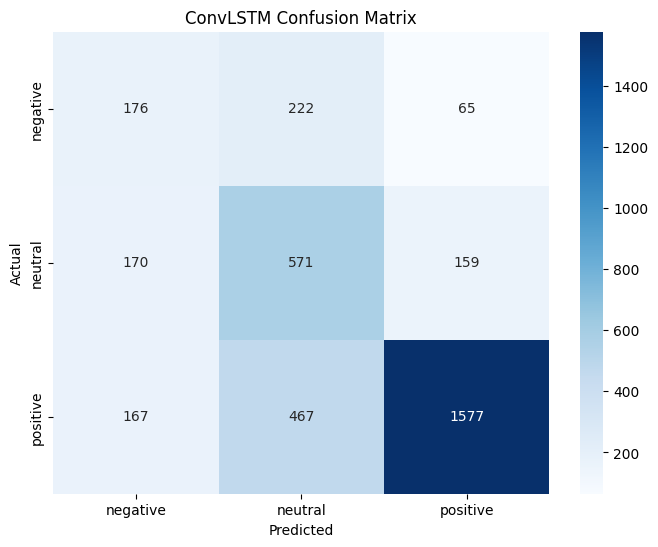

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "negative",
        "neutral",
        "positive"
    ],
    yticklabels=[
        "negative",
        "neutral",
        "positive"
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("ConvLSTM Confusion Matrix")

plt.show()

In [39]:
torch.save(
    model.state_dict(),
    "../models/convlstm_model.pth"
)

print(
    "ConvLSTM model saved!"
)

ConvLSTM model saved!


In [40]:
with open(
    "../models/vocab.pkl",
    "wb"
) as f:

    pickle.dump(
        vocab,
        f
    )